In [ ]:
import numpy as np
import pandas as pd
import json
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


# Загрузка данных
with open("rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features_df = pd.read_csv('DATA/Features/REAL_features_ws32_overlap75.csv')

X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

Размерность данных: (16639, 50)
Уникальные классы: [0 1 2 3 4 5]
Выполняется PCA...
PCA завершен. Объясненная дисперсия: 0.673
Выполняется t-SNE (это может занять время)...


C:\Users\cvarc\anaconda3\envs\env\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\cvarc\anaconda3\envs\env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


t-SNE завершен


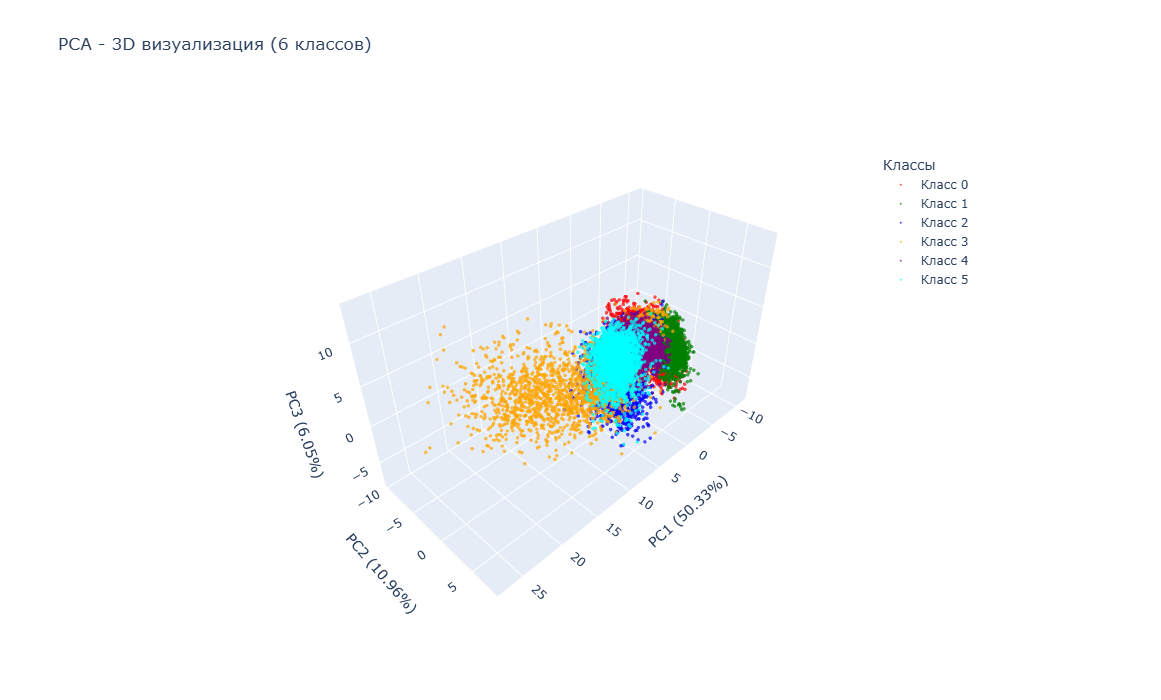

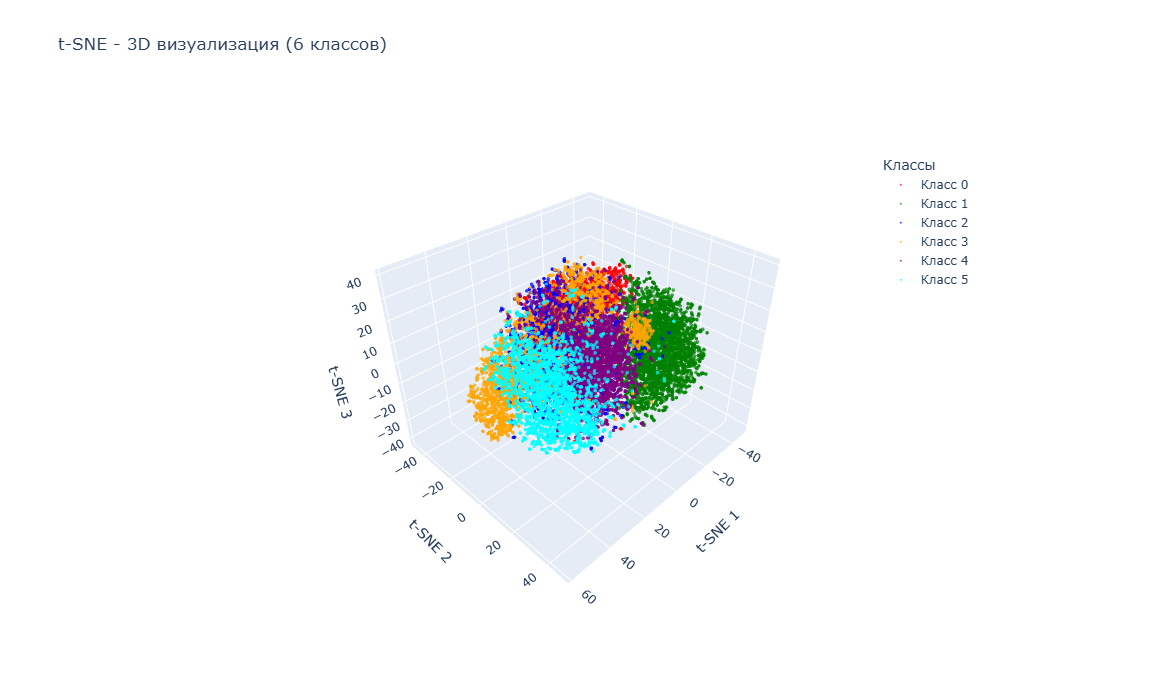


Статистика по классам:
Класс 0: 2381 samples
Класс 1: 3797 samples
Класс 2: 2572 samples
Класс 3: 2474 samples
Класс 4: 2747 samples
Класс 5: 2668 samples


In [1]:
num_of_features = len(file["optimal_features"])
num_of_features = 50
features = file["optimal_features"][:num_of_features]
new_X = X[features]

# Масштабирование данных (важно для PCA и t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(new_X)

print(f"Размерность данных: {X_scaled.shape}")
print(f"Уникальные классы: {np.unique(y)}")

# Определяем количество уникальных классов
unique_classes = np.unique(y)
n_classes = len(unique_classes)


colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA завершен. Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE
tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE завершен")

# Функция для создания 3D графика
def create_3d_plot(X_transformed, y, method_name, colors_list, feature_names=None):
    fig = go.Figure()
    
    # Для каждого класса создаем отдельный trace
    for i, class_val in enumerate(unique_classes):
        # Получаем индексы текущего класса
        class_indices = y == class_val
        
        fig.add_trace(go.Scatter3d(
            x=X_transformed[class_indices, 0],
            y=X_transformed[class_indices, 1],
            z=X_transformed[class_indices, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=colors_list[i % len(colors_list)],
                opacity=0.7,
                line=dict(width=0)
            ),
            name=f'Класс {class_val}'
        ))
    
    # Настройка осей
    if feature_names:
        x_title, y_title, z_title = feature_names
    else:
        x_title, y_title, z_title = 'PC1', 'PC2', 'PC3'
    
    fig.update_layout(
        title=f'{method_name} - 3D визуализация ({n_classes} классов)',
        scene=dict(
            xaxis_title=x_title,
            yaxis_title=y_title,
            zaxis_title=z_title,
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        legend=dict(
            title='Классы',
            x=0.8,
            y=0.9,
            bgcolor='rgba(255, 255, 255, 0.8)'
        ),
        width=1000,
        height=700,
        hovermode='closest'
    )
    
    return fig

# Создаем графики
fig_pca = create_3d_plot(
    X_pca, 
    y, 
    'PCA', 
    colors, 
    feature_names=[f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', 
                   f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', 
                   f'PC3 ({pca.explained_variance_ratio_[2]:.2%})']
)

fig_tsne = create_3d_plot(
    X_tsne, 
    y, 
    't-SNE', 
    colors, 
    feature_names=['t-SNE 1', 't-SNE 2', 't-SNE 3']
)

fig_pca.show()
fig_tsne.show()

print("\nСтатистика по классам:")
for class_val in unique_classes:
    count = np.sum(y == class_val)
    print(f"Класс {class_val}: {count} samples")

Размерность данных: (16639, 264)
Уникальные классы: [0 1 2 3 4 5]
Выполняется PCA...
PCA завершен. Объясненная дисперсия: 0.435
Выполняется t-SNE (это может занять время)...
t-SNE завершен


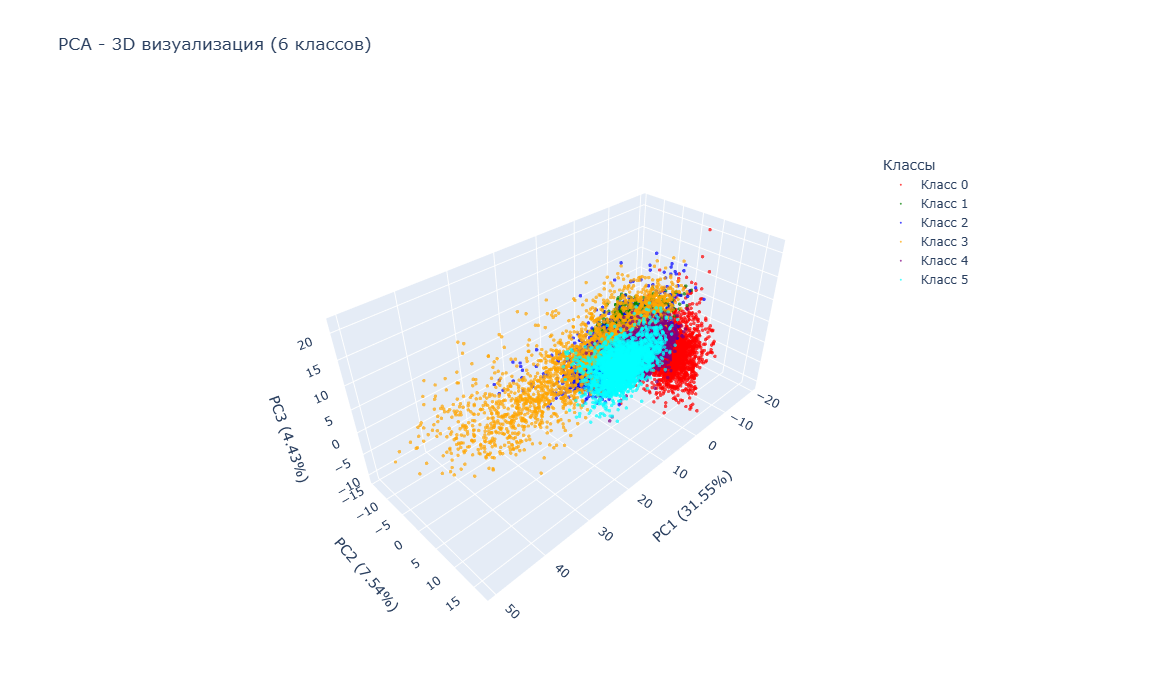

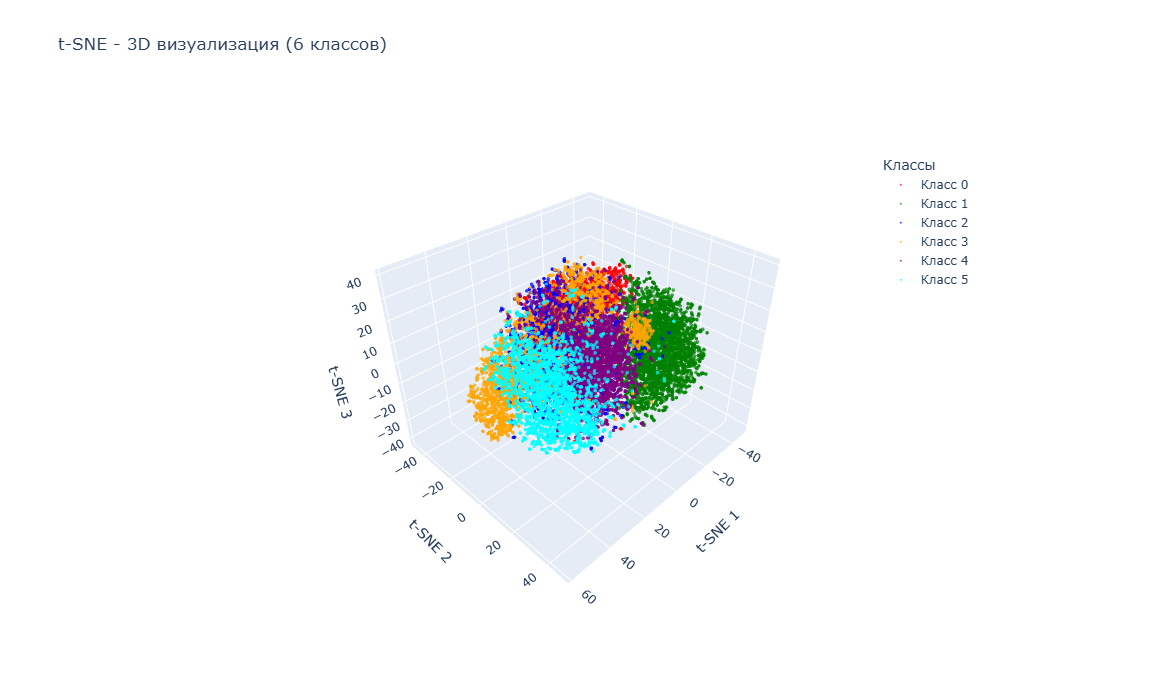


Статистика по классам:
Класс 0: 2381 samples
Класс 1: 3797 samples
Класс 2: 2572 samples
Класс 3: 2474 samples
Класс 4: 2747 samples
Класс 5: 2668 samples


In [2]:
# Выбор оптимальных признаков
num_of_features = len(file["optimal_features"])
# num_of_features = 50
features = file["optimal_features"][:num_of_features]
new_X = X[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(new_X)

print(f"Размерность данных: {X_scaled.shape}")
print(f"Уникальные классы: {np.unique(y)}")

# Определяем количество уникальных классов
unique_classes = np.unique(y)
n_classes = len(unique_classes)


colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA завершен. Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE
# tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
# X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE завершен")

def create_3d_plot(X_transformed, y, method_name, colors_list, feature_names=None):
    fig = go.Figure()
    
    for i, class_val in enumerate(unique_classes):
        class_indices = y == class_val
        
        fig.add_trace(go.Scatter3d(
            x=X_transformed[class_indices, 0],
            y=X_transformed[class_indices, 1],
            z=X_transformed[class_indices, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=colors_list[i % len(colors_list)],
                opacity=0.7,
                line=dict(width=0)
            ),
            name=f'Класс {class_val}'
        ))
    
    if feature_names:
        x_title, y_title, z_title = feature_names
    else:
        x_title, y_title, z_title = 'PC1', 'PC2', 'PC3'
    
    fig.update_layout(
        title=f'{method_name} - 3D визуализация ({n_classes} классов)',
        scene=dict(
            xaxis_title=x_title,
            yaxis_title=y_title,
            zaxis_title=z_title,
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        legend=dict(
            title='Классы',
            x=0.8,
            y=0.9,
            bgcolor='rgba(255, 255, 255, 0.8)'
        ),
        width=1000,
        height=700,
        hovermode='closest'
    )
    
    return fig

fig_pca = create_3d_plot(
    X_pca, 
    y, 
    'PCA', 
    colors, 
    feature_names=[f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', 
                   f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', 
                   f'PC3 ({pca.explained_variance_ratio_[2]:.2%})']
)

fig_tsne = create_3d_plot(
    X_tsne, 
    y, 
    't-SNE', 
    colors, 
    feature_names=['t-SNE 1', 't-SNE 2', 't-SNE 3']
)

fig_pca.show()
fig_tsne.show()

# Дополнительно: статистика по классам
print("\nСтатистика по классам:")
for class_val in unique_classes:
    count = np.sum(y == class_val)
    print(f"Класс {class_val}: {count} samples")